In [1]:
%cd ..

/home/dev/workspace


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-08-04_00-05-57/saved/checkpoint-epoch50.npy", "+experiment=poisson_convsc",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

E0804 18:02:55.267335    7181 ptx_compiler_helpers.cc:157] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [5]:
metrics

{'loss': np.float32(-2.4264168e+06),
 'log_w': np.float32(2.426417e+06),
 'nll': np.float32(-75960.7),
 'kl': np.float32(135.16988),
 'log_Z': np.float32(-25756.25),
 'ess': np.float32(0.25)}

In [6]:
for data, target in objects['datamodule'].valid_dataloader():
    metrics, predictions = objects['learner'](data, stage="valid")
    break

/home/dev/workspace/src/inference/tracer.py:132: UserWarning: Found vars in model but not guide: {'obs'}
  check_model_guide_match(model_trace, guide_trace)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5206328..1.0000026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.50655085..1.0000317].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5245619..1.000018].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5218464..1.0000083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.51610494..1.00002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.51576954..1.0000035].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.51673126..1.0

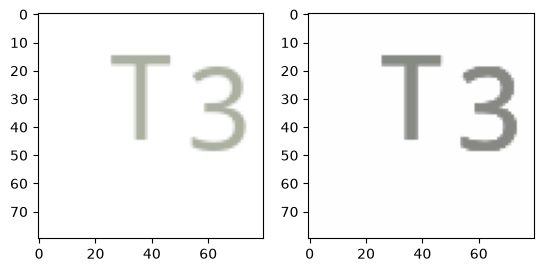

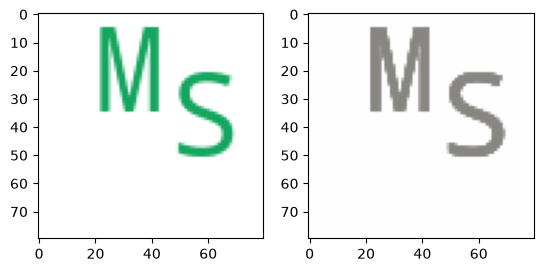

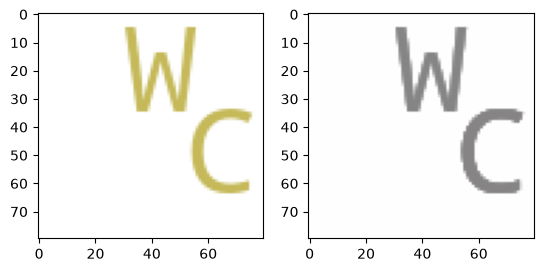

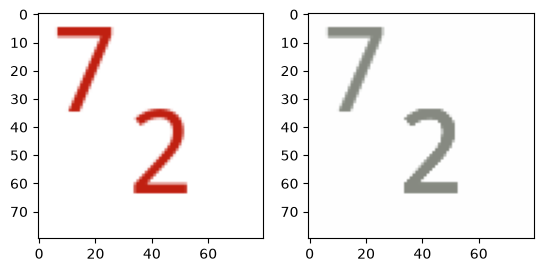

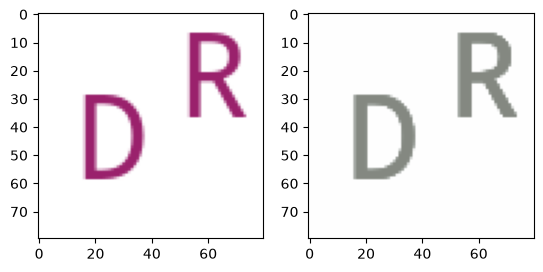

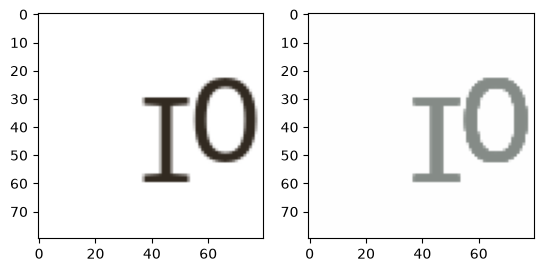

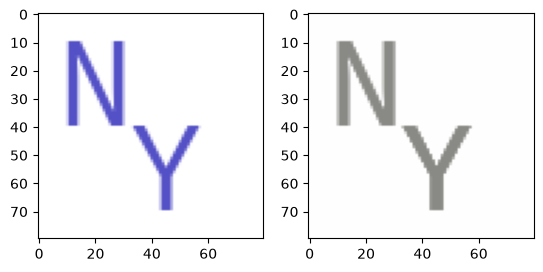

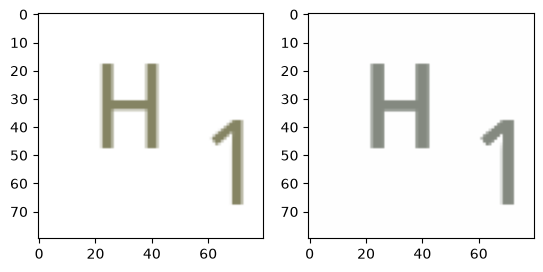

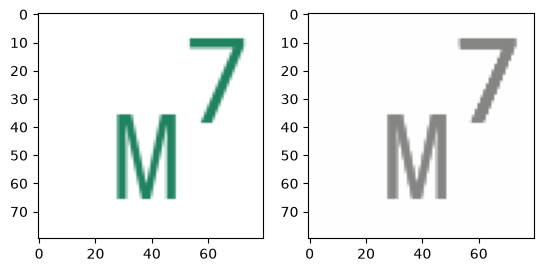

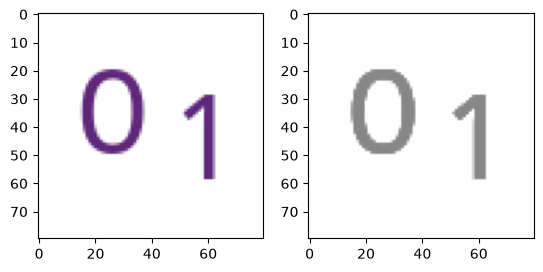

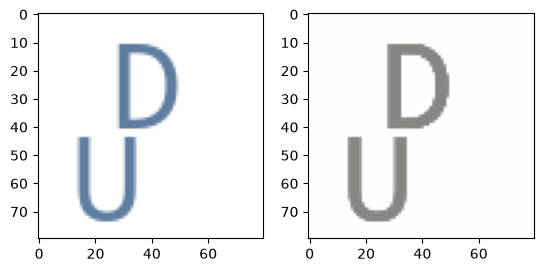

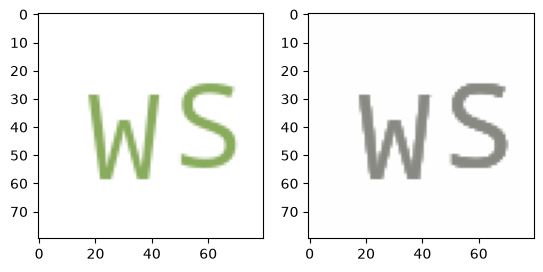

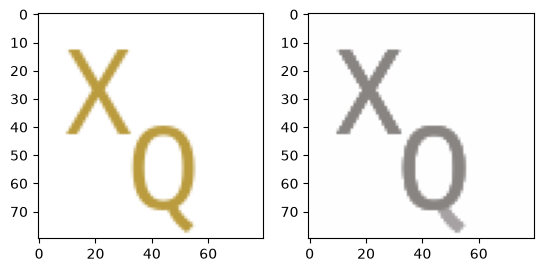

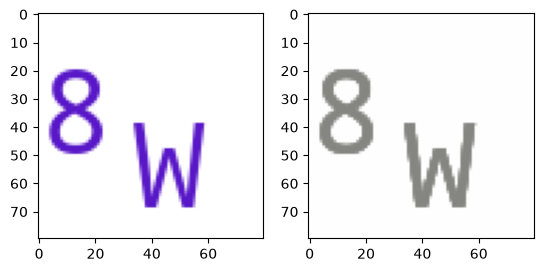

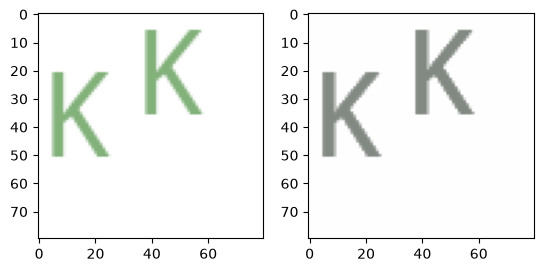

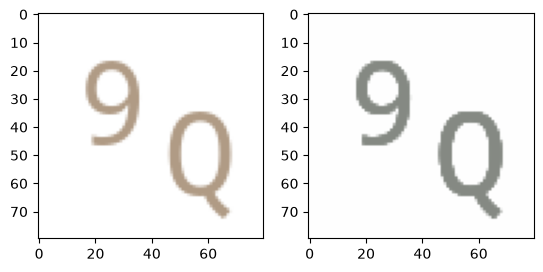

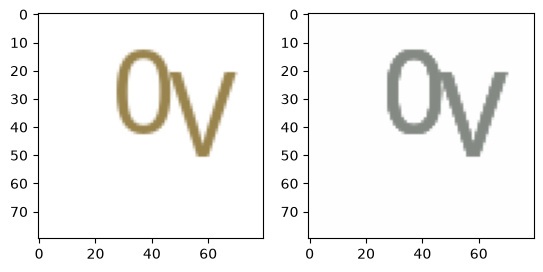

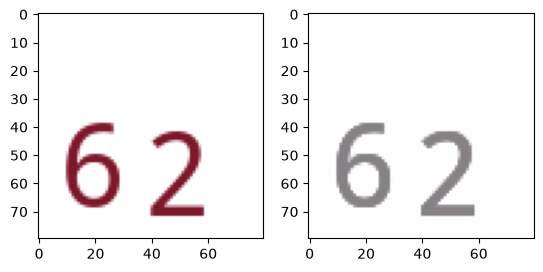

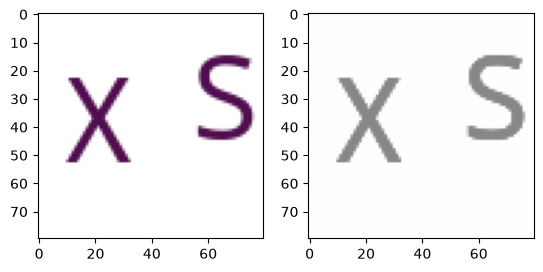

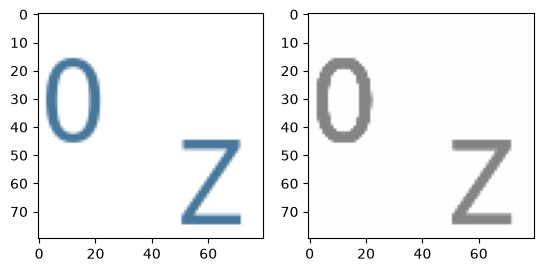

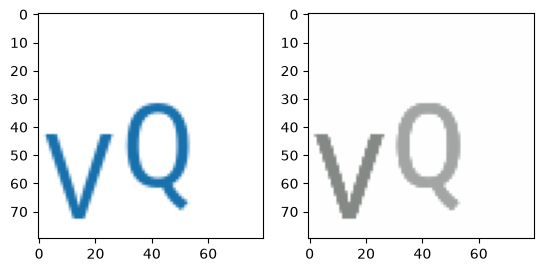

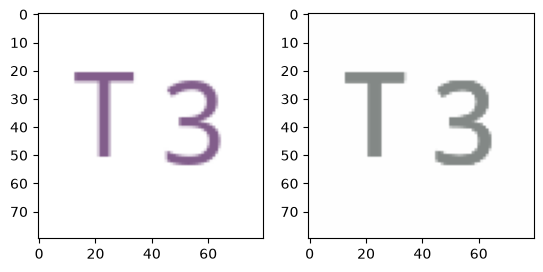

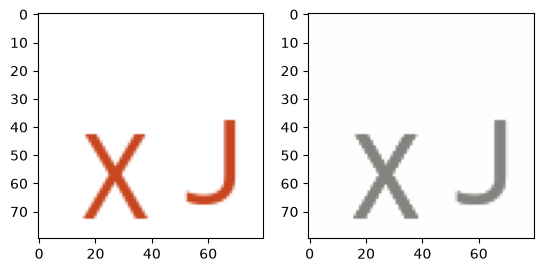

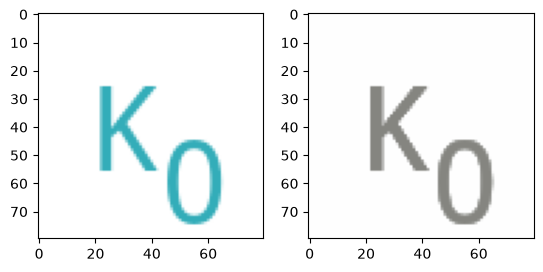

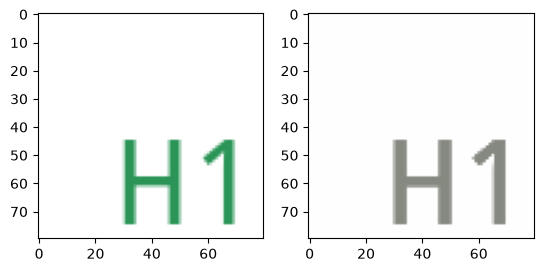

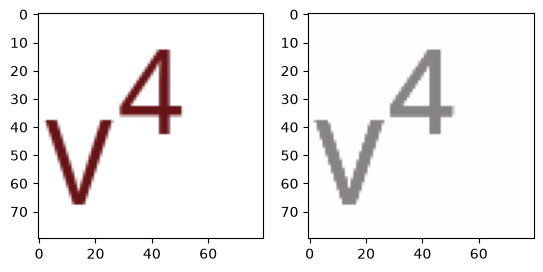

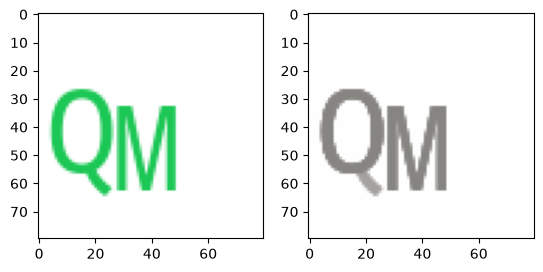

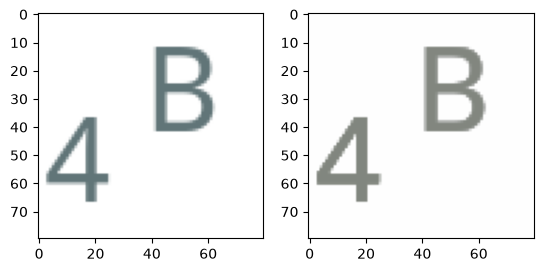

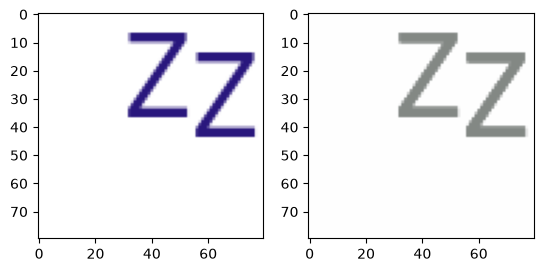

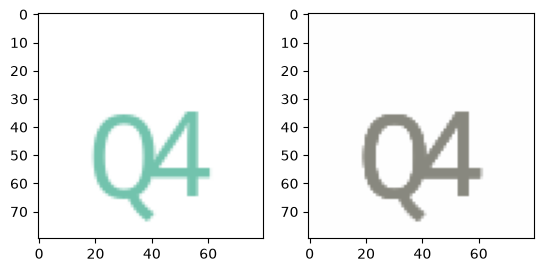

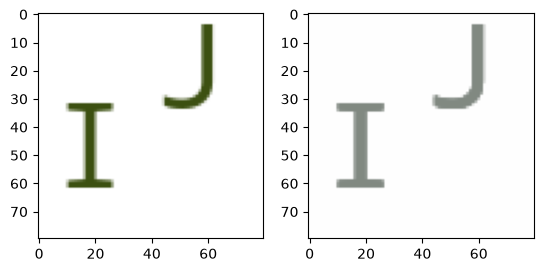

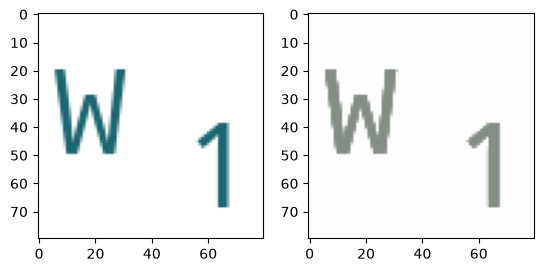

In [7]:
for i in range(data.shape[0]):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(data[i])
    axes[1].imshow(predictions["obs"]["ev"].mean(axis=0)[i])